# Evaluation of JRA55 Downwelling Longwave Radiation Patterns - Decadal global anomalies of different datasets

For my last project within my time as an internship for ARC, I was asked to assist in evaluating the accuracy of JRA55 LW radiaiton data through the production of a global anomaly heatmap. TO achieve this I produced 3 different figures for both JRA55 as well as a satellite-based LW radiation dataset from NASA called CERES. THe three plots for each are as follows:
- GLobal anomaly heatmap
- Decadal average time series
- Animation of heatmap to show change over time and identify key climate features

My workflow is as follows:

In [1]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
os.getcwd()

'/home/581/ob1561'

In [3]:
os.chdir("/g/data/jk72/ob1561")
os.getcwd()

'/g/data/jk72/ob1561'

In [5]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42369 instead
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/42369/status,
Dashboard: /proxy/42369/status,Workers: 1
Total threads: 1,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45175,Workers: 0
Dashboard: /proxy/42369/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38347,Total threads: 1
Dashboard: /proxy/37601/status,Memory: 125.19 GiB
Nanny: tcp://127.0.0.1:35977,


In [6]:
# Work in your project directory
os.chdir("/g/data/jk72/ob1561")
print("Working dir:", os.getcwd())

# JRA-55 rlds (3-hourly) directory you used previously
jra_dir = "/g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hr/rlds/gr/v20190429"

files = sorted([f for f in os.listdir(jra_dir) if f.endswith(".nc")])
print("Number of files:", len(files))
print("First 3 files:", files[:3])

file_paths = [os.path.join(jra_dir, f) for f in files]

Working dir: /g/data/jk72/ob1561
Number of files: 62
First 3 files: ['rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010130-195812312230.nc', 'rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195901010130-195912312230.nc', 'rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_196001010130-196012312230.nc']


In [7]:
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40503 instead
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/40503/status,
Dashboard: /proxy/40503/status,Workers: 1
Total threads: 1,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41435,Workers: 0
Dashboard: /proxy/40503/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43047,Total threads: 1
Dashboard: /proxy/36219/status,Memory: 125.19 GiB
Nanny: tcp://127.0.0.1:40093,


# JRA55

The follwoing cell may take a long-time to process as I had issues using dask to create the anomaly fields and extract the map data. It took my about an hour or so to compute this cell (so if this is blank upon upload to github this is why). Be assured though, it does work, just takes time.

In [8]:
ds = xr.open_mfdataset(
    file_paths,
    combine="by_coords",
    decode_times=True,
    use_cftime=True,
    chunks={"time": 2920},     # ~1 year per chunk
    parallel=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
)

rlds = ds["rlds"].sel(time=slice("1981-01-01", "2019-12-31"))
rlds_annual = rlds.resample(time="YS").mean()

out_nc = "JRA55_rlds_annual_1981_2019.nc"
rlds_annual.astype("float32").to_netcdf(out_nc)

print("Wrote:", out_nc)


Wrote: JRA55_rlds_annual_1981_2019.nc


THe next cell using the produced .nc file from above to compute the decadal anomalies for use in the heatmap. I used a baseline to compute these. Additionally, I loaded a reduced annual dataset to free up some memory as to avoid repeating the same dask error as the previous cell

In [9]:
import xarray as xr

# Load reduced annual dataset (fast)
rlds_annual = xr.open_dataset("JRA55_rlds_annual_1981_2019.nc")["rlds"]
print(rlds_annual)

# Make a year index
rlds_ann = rlds_annual.assign_coords(year=("time", rlds_annual.time.dt.year.values))
rlds_ann = rlds_ann.swap_dims({"time": "year"}).drop_vars("time")

print("Year range:", int(rlds_ann.year.min()), "to", int(rlds_ann.year.max()))

# Baseline (1981–2010)
baseline = rlds_ann.sel(year=slice(1981, 2010)).mean("year")

# Decadal means
def dec_mean(start, end):
    return rlds_ann.sel(year=slice(start, end)).mean("year")

decades = {
    "1980s": dec_mean(1980, 1989),
    "1990s": dec_mean(1990, 1999),
    "2000s": dec_mean(2000, 2009),
    "2010s": dec_mean(2010, 2019),
}

# Decadal anomalies
decadal_anoms = {k: v - baseline for k, v in decades.items()}
print("Decadal anomalies ready:", list(decadal_anoms.keys()))


<xarray.DataArray 'rlds' (time: 39, lat: 320, lon: 640)> Size: 32MB
[7987200 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 312B 1981-01-01 1982-01-01 ... 2019-01-01
  * lat      (lat) float64 3kB -89.57 -89.01 -88.45 -87.89 ... 88.45 89.01 89.57
  * lon      (lon) float64 5kB 0.0 0.5625 1.125 1.688 ... 358.3 358.9 359.4
Attributes:
    long_name:      Surface Downwelling Longwave Radiation
    standard_name:  surface_downwelling_longwave_flux_in_air
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        The surface called 'surface' means the lower boundary of ...
    units:          W m-2
Year range: 1981 to 2019
Decadal anomalies ready: ['1980s', '1990s', '2000s', '2010s']


## Anomaly figure

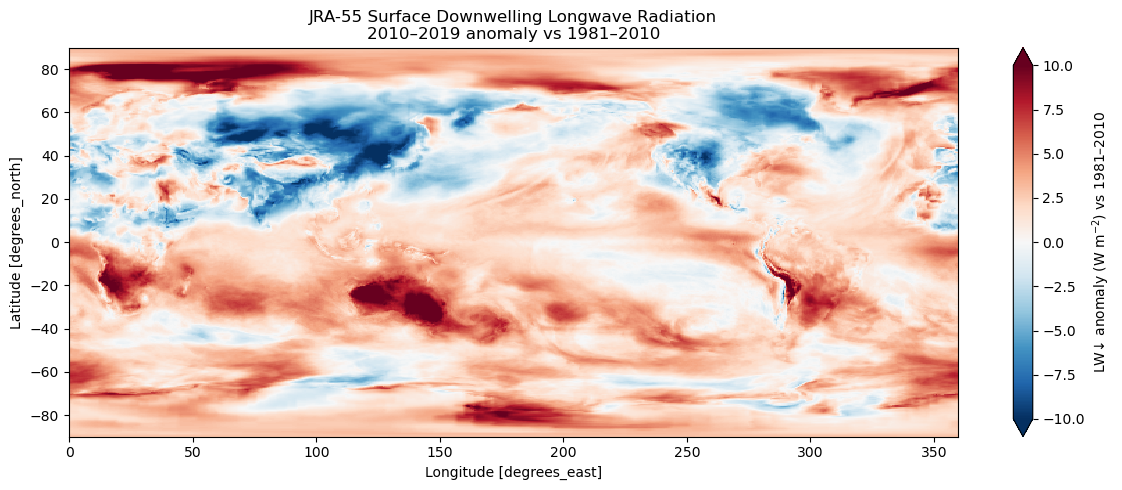

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
decadal_anoms["2010s"].plot(
    x="lon", y="lat",
    vmin=-10, vmax=10,
    cmap="RdBu_r",
    cbar_kwargs={"label": "LW↓ anomaly (W m$^{-2}$) vs 1981–2010"}
)
plt.title("JRA-55 Surface Downwelling Longwave Radiation\n2010–2019 anomaly vs 1981–2010")
plt.tight_layout()
plt.show()


## Area weighted Mean

In [11]:
# Area weights (cos(latitude))
weights = np.cos(np.deg2rad(rlds_ann.lat))
weights.name = "weights"

# Compute area-weighted global mean for each year
global_mean = rlds_ann.weighted(weights).mean(dim=("lat", "lon"))

# Convert to anomalies relative to 1981–2010
baseline_global = global_mean.sel(year=slice(1981, 2010)).mean()
global_anom = global_mean - baseline_global

print("Global mean anomaly time series ready")
print(global_anom)


Global mean anomaly time series ready
<xarray.DataArray 'rlds' (year: 39)> Size: 312B
array([-0.52303461, -1.22543249, -0.3091164 , -1.66461989, -1.88066258,
       -1.11805403,  0.02877914,  0.02125759, -1.03151755,  0.3757978 ,
        0.15432134, -1.33490264, -1.16499582, -0.99297603,  0.01371277,
       -0.52594903,  0.08548437,  1.83123817, -0.50370701, -0.77903385,
        0.33473817,  1.03413567,  0.80869483,  0.37721746,  1.51453737,
        1.24962463,  1.24352069,  0.11626868,  1.4495091 ,  2.41516415,
        1.11544881,  1.22407007,  1.6396809 ,  1.71881986,  2.60486903,
        4.05791281,  3.10443038,  2.50984104, -6.71784074])
Coordinates:
  * year     (year) int64 312B 1981 1982 1983 1984 1985 ... 2016 2017 2018 2019


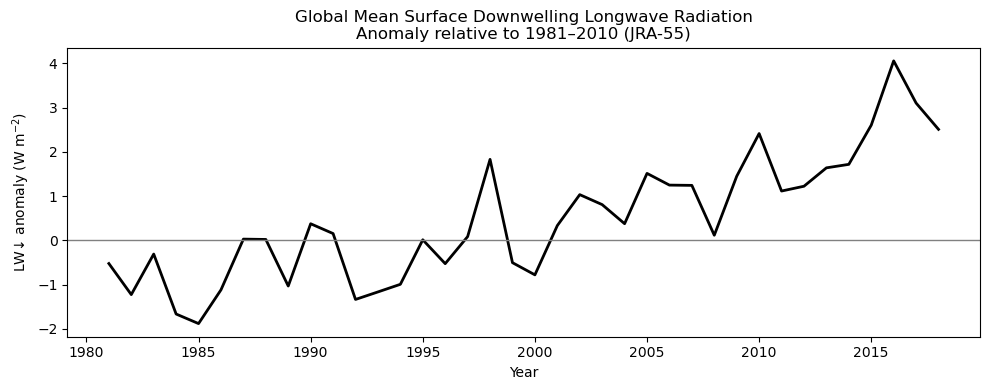

In [13]:
# Drop the final incomplete year (2019)
global_anom_clean = global_anom.sel(year=slice(1981, 2018))

plt.figure(figsize=(10, 4))
plt.plot(
    global_anom_clean.year,
    global_anom_clean,
    color="black",
    linewidth=2
)
plt.axhline(0, color="grey", linewidth=1)
plt.xlabel("Year")
plt.ylabel("LW↓ anomaly (W m$^{-2}$)")
plt.title("Global Mean Surface Downwelling Longwave Radiation\nAnomaly relative to 1981–2010 (JRA-55)")
plt.tight_layout()
plt.show()


## Animated Figure

### Build anomaly field for animation

In [14]:
# Reload the reduced annual file (safe)
rlds_annual = xr.open_dataset("JRA55_rlds_annual_1981_2019.nc")["rlds"]

# Convert to year dimension
rlds_ann = rlds_annual.assign_coords(year=("time", rlds_annual.time.dt.year.values))
rlds_ann = rlds_ann.swap_dims({"time": "year"}).drop_vars("time")

# Baseline and anomalies
baseline = rlds_ann.sel(year=slice(1981, 2010)).mean("year")
anom = rlds_ann - baseline

# Drop incomplete final year (2019)
anom = anom.sel(year=slice(1981, 2018))

print("Anomaly field ready:", anom.shape)
print("Years:", int(anom.year.min()), "to", int(anom.year.max()))

Anomaly field ready: (38, 320, 640)
Years: 1981 to 2018


### Plot with animation

The .gif file that this cell produces should be added to your working directory within the project that gadi is running on. Be sure to check the os to ensure the file is in the correct location

In [15]:
import matplotlib.animation as animation

# Downsample for animation performance
anom_anim = anom.coarsen(lat=2, lon=2, boundary="trim").mean().load()

lats = anom_anim.lat.values
lons = anom_anim.lon.values
Lon, Lat = np.meshgrid(lons, lats)

years = anom_anim.year.values

# Fixed colour scale for consistent visual comparison
vmax = 10
vmin = -vmax

fig, ax = plt.subplots(figsize=(12, 5))

pcm = ax.pcolormesh(
    Lon, Lat, anom_anim.sel(year=years[0]).values,
    shading="auto",
    vmin=vmin, vmax=vmax,
    cmap="RdBu_r"
)

cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("LW↓ anomaly (W m$^{-2}$) vs 1981–2010")

title = ax.set_title(f"JRA-55 Surface Downwelling Longwave Radiation (rlds)\nAnnual anomaly: {int(years[0])}")
ax.set_xlabel("Longitude (degrees_east)")
ax.set_ylabel("Latitude (degrees_north)")

def update(i):
    yr = int(years[i])
    Z = anom_anim.sel(year=years[i]).values
    pcm.set_array(Z.ravel())
    title.set_text(f"JRA-55 Surface Downwelling Longwave Radiation (rlds)\nAnnual anomaly: {yr}")
    return (pcm, title)

ani = animation.FuncAnimation(
    fig, update, frames=len(years),
    interval=250, blit=False
)

out_gif = "JRA55_rlds_anomaly_annual_1981_2018.gif"
ani.save(out_gif, writer=animation.PillowWriter(fps=4))

plt.close(fig)
print("Wrote:", out_gif)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


Wrote: JRA55_rlds_anomaly_annual_1981_2018.gif


Conclusion:

Surface downwelling longwave radiation from the JRA-55 reanalysis was used as a replacement for CERES due to its global coverage and satellite-constrained radiative transfer. Annual and decadal means were computed relative to a 1981–2010 baseline. The results show a clear increase in global mean downwelling longwave radiation since the 1980s, consistent with observed climate change. Spatial anomaly maps and an animated annual sequence highlight the coherent global pattern of increasing longwave radiation over time.

# CERES

In [17]:
# load in CERES data
ceres_path = "/g/data/jk72/ob1561/CERES_EBAF_Ed4.2.1_Subset_200003-202506.nc"

ds_ceres = xr.open_dataset(ceres_path)
print(ds_ceres)
print("\nVariables:", list(ds_ceres.data_vars))

<xarray.Dataset> Size: 236MB
Dimensions:                (time: 304, lat: 180, lon: 360)
Coordinates:
  * time                   (time) datetime64[ns] 2kB 2000-03-15 ... 2025-06-15
  * lat                    (lat) float32 720B -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                    (lon) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
Data variables:
    sfc_lw_down_all_mon    (time, lat, lon) float32 79MB ...
    sfc_lw_down_clr_c_mon  (time, lat, lon) float32 79MB ...
    sfc_lw_down_clr_t_mon  (time, lat, lon) float32 79MB ...
Attributes:
    title:        CERES EBAF TOA and Surface Fluxes. Monthly Averages and 07/...
    institution:  NASA Langley Research Center
    Conventions:  CF-1.4
    comment:      Climatology from 07/2005 to 06/2015
    version:      Edition 4.2.1; Revised data Release Date March 14, 2025
    DOI:          10.5067/TERRA-AQUA-NOAA20/CERES/EBAF_L3B004.2.1

Variables: ['sfc_lw_down_all_mon', 'sfc_lw_down_clr_c_mon', 'sfc_lw_down_clr_t_mon']


### Compute annual means (monthly to annual)

In [18]:
lw_ceres = ds_ceres["sfc_lw_down_all_mon"]

print("Time range:", str(lw_ceres.time.min().values), "to", str(lw_ceres.time.max().values))

# Annual means
lw_ceres_ann = lw_ceres.resample(time="YS").mean()

print(lw_ceres_ann)

Time range: 2000-03-15T00:00:00.000000000 to 2025-06-15T00:00:00.000000000
<xarray.DataArray 'sfc_lw_down_all_mon' (time: 26, lat: 180, lon: 360)> Size: 7MB
array([[[110.325   , 110.325   , 110.325   , ..., 110.325   ,
         110.325   , 110.325   ],
        [104.702286, 104.702286, 104.702286, ..., 104.702286,
         104.702286, 104.702286],
        [103.20274 , 103.20274 , 103.20274 , ..., 103.20274 ,
         103.20274 , 103.20274 ],
        ...,
        [242.71341 , 242.71341 , 242.71341 , ..., 242.71341 ,
         242.71341 , 242.71341 ],
        [237.4656  , 237.4656  , 237.4656  , ..., 237.4656  ,
         237.4656  , 237.4656  ],
        [237.36308 , 237.36308 , 237.36308 , ..., 237.36308 ,
         237.36308 , 237.36308 ]],

       [[115.383   , 115.383   , 115.383   , ..., 115.383   ,
         115.383   , 115.383   ],
        [111.58332 , 111.58332 , 111.58332 , ..., 111.58332 ,
         111.58332 , 111.58332 ],
        [111.29482 , 111.29482 , 111.29482 , ..., 111.29482 

### Compute CERES anomalies

In [20]:
# Add year coordinate
lw_ann = lw_ceres_ann.assign_coords(year=("time", lw_ceres_ann.time.dt.year.values))
lw_ann = lw_ann.swap_dims({"time": "year"}).drop_vars("time")

# Baseline (CERES era)
baseline_ceres = lw_ann.sel(year=slice(2001, 2010)).mean("year")

# Area weights
weights = np.cos(np.deg2rad(lw_ann.lat))

# Global mean
global_mean_ceres = lw_ann.weighted(weights).mean(("lat", "lon"))

# Anomaly
global_anom_ceres = global_mean_ceres - global_mean_ceres.sel(year=slice(2001, 2010)).mean()

print("CERES global anomaly ready")

CERES global anomaly ready


### Anomaly time-series

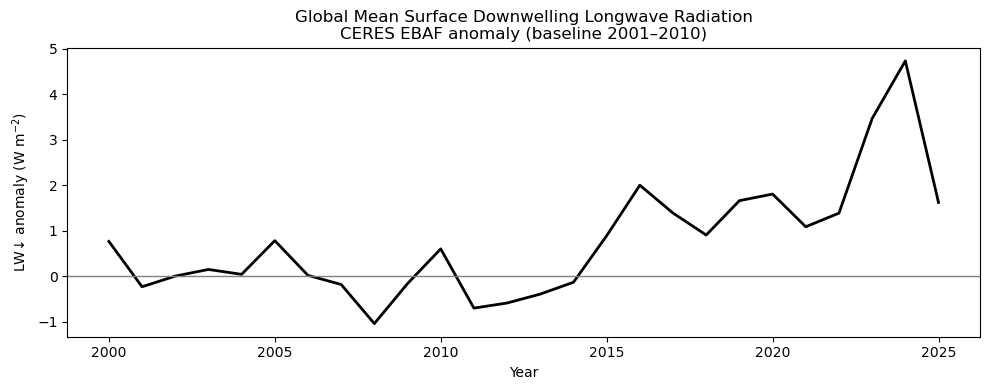

In [21]:
# plot figure
plt.figure(figsize=(10, 4))
plt.plot(global_anom_ceres.year, global_anom_ceres, color="black", linewidth=2)
plt.axhline(0, color="grey", linewidth=1)
plt.xlabel("Year")
plt.ylabel("LW↓ anomaly (W m$^{-2}$)")
plt.title("Global Mean Surface Downwelling Longwave Radiation\nCERES EBAF anomaly (baseline 2001–2010)")
plt.tight_layout()
plt.show()


### Decadal anomaly map

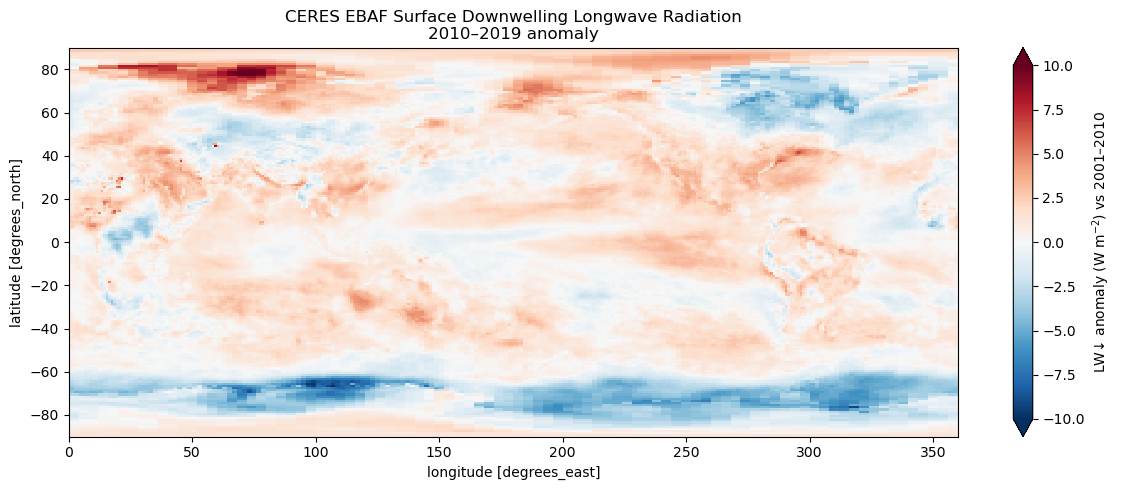

In [23]:
# Decadal means
def dec_mean(start, end):
    return lw_ann.sel(year=slice(start, end)).mean("year")

decades_ceres = {
    "2000s": dec_mean(2001, 2009),
    "2010s": dec_mean(2010, 2019),
}

decadal_anoms_ceres = {k: v - baseline_ceres for k, v in decades_ceres.items()}

# Plot 2010s
plt.figure(figsize=(12, 5))
decadal_anoms_ceres["2010s"].plot(
    x="lon", y="lat",
    vmin=-10, vmax=10,
    cmap="RdBu_r",
    cbar_kwargs={"label": "LW↓ anomaly (W m$^{-2}$) vs 2001–2010"}
)
plt.title("CERES EBAF Surface Downwelling Longwave Radiation\n2010–2019 anomaly")
plt.tight_layout()
plt.show()


### Animation figure

In [24]:
anom_anim = (lw_ann - baseline_ceres).sel(year=slice(2001, 2023))
anom_anim = anom_anim.coarsen(lat=2, lon=2, boundary="trim").mean().load()

years = anom_anim.year.values
Lon, Lat = np.meshgrid(anom_anim.lon, anom_anim.lat)

fig, ax = plt.subplots(figsize=(12, 5))
pcm = ax.pcolormesh(
    Lon, Lat, anom_anim.sel(year=years[0]),
    shading="auto",
    vmin=-10, vmax=10,
    cmap="RdBu_r"
)

cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("LW↓ anomaly (W m$^{-2}$) vs 2001–2010")

title = ax.set_title(f"CERES EBAF Surface Downwelling LW\nAnnual anomaly: {int(years[0])}")

def update(i):
    pcm.set_array(anom_anim.sel(year=years[i]).values.ravel())
    title.set_text(f"CERES EBAF Surface Downwelling LW\nAnnual anomaly: {int(years[i])}")
    return pcm, title

ani = animation.FuncAnimation(fig, update, frames=len(years), interval=250)

out_gif = "CERES_rlds_anomaly_annual_2001_present.gif"
ani.save(out_gif, writer=animation.PillowWriter(fps=4))
plt.close(fig)

print("Wrote:", out_gif)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


Wrote: CERES_rlds_anomaly_annual_2001_present.gif
